<a href="https://colab.research.google.com/github/tamyressilvazz/VisaoComputacionalDeepLearning/blob/main/Projeto_Visao_Computacional_com_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Projeto - Visao Computacional com Deep Learning

#### Marianne Félix e Tamyres Bezerra


---


Este projeto, desenvolvido como parte da avaliação final da disciplina utiliza o conjunto de dados EuroSAT, composto por imagens de satélite do Sentinel-2.


### Descrição do problema a ser resolvido
Classificar, a partir de imagens multiespectrais de satélite, o uso/cobertura do solo que está sendo representada. O conjunto de dados é composto por aproximadamente 27.000 imagens de 64×64 pixels, organizadas em 10 categorias distintas, incluindo floresta, rodovia, área industrial, cultivo permanente e residencial. As imagens a serem utilizadas está no formato RGB (3 bandas).

Tópicos abordados:


*   Carregamento e pré-processamento dos dados
*   Modelagem(com e sem transfer learning)
*   Visualizações e avaliação



### Importe das bibliotecas utilizadas

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import random

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.optimizer import R
import torch.optim as optim
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


### Carregamento dos dados

Nas células abaixo temos alguns processos importantes para o carregamento das imagens:


*   Conversão das imagens para tensor;
*   Carregamento do dataset usando a classe base fornecida pelo PyTorch
`datasets.EuroSAT`;
* Labels das imagens;
* Análise das imagens




In [ ]:
#Carregando o dataset
path = "./dataset"

dataset = datasets.EuroSAT(root = path, transform = transforms.Compose([transforms.ToTensor()]), download = True)


100%|██████████| 94.3M/94.3M [00:00<00:00, 427MB/s]


In [ ]:
#Rótulos do dataset
dataset.class_to_idx

{'AnnualCrop': 0,
 'Forest': 1,
 'HerbaceousVegetation': 2,
 'Highway': 3,
 'Industrial': 4,
 'Pasture': 5,
 'PermanentCrop': 6,
 'Residential': 7,
 'River': 8,
 'SeaLake': 9}

As imagens obtidas pelo satélite são exibidas de forma aleatória abaixo. Aparentemente a qualidade de algumas imagens não é muito boa e isso pode resultar em dificuldade do modelo de aprender determinados padrões durante o treinamento para fazer as classificações da forma correta, especialmente se tiver poucas imagens de um certo tipo de classe. Há casos também em que a imagem possue rótulo mas com a visão obstruída parcial ou totalmente. Se a rede não aprender bem o suficiente, será necessário usar uma técnica chamada data augmentation para aumentar a diversidade das imagens.

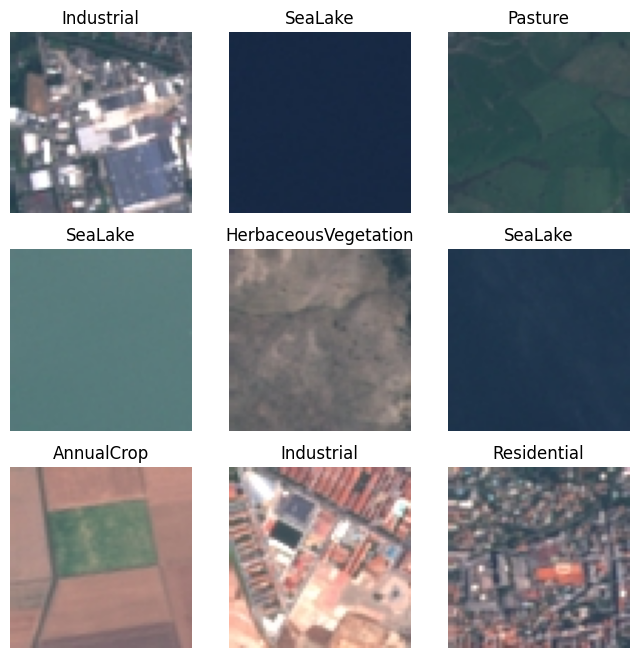

In [ ]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
num_images = 9

for i in range(1, num_images +1):
  img, label = random.choice(dataset) #Escolhe uma imagem aleatória do dataset
  img = np.transpose(img.numpy())
  figure.add_subplot(rows, cols, i)
  plt.title(dataset.classes[label])
  plt.imshow(img)
  plt.axis("off")

plt.show()

## CNN Própria

### Pré-processamento dos dados

Nas células abaixo temos alguns processos importantes para o pré-processamento das imagens:

*   Normalização das imagens;
* Definição tamanho e conjunto de treino, validação e teste;
*   Criação do dataloader para iterar sobre as imagens que serão separadas em lotes para separar em conjunto de treino, teste e validação

In [ ]:
# Normalização aplicada para ajustar os valores dos pixels para ajudar as redes neurais a aprenderem melhor.
# Esses são os valores mais comuns encontrados
dataset.transform.transforms.append(transforms.Normalize(
    mean=[0.3443,0.3809,0.4082],
    std=[0.1848,0.1556,0.1266])
)

In [ ]:
# Separando dados para treinamento(70%), teste(15%) e validação(15%)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 1 - train_ratio - val_ratio

dataset_size = len(dataset)
train_size = int(dataset_size * train_ratio)
validation_size = int(dataset_size * val_ratio)
test_size = dataset_size - train_size - validation_size

print(f"Quantidade total de imagens: {dataset_size}")
print(f"Quantidade total de imagens para treino: {train_size}")
print(f"Quantidade total de imagens para teste: {test_size}")
print(f"Quantidade total de imagens para validação: {validation_size}")

# Criando um seed para gerar sempre as mesmas amostras
generator = torch.Generator().manual_seed(42)


# Selecionando dados aleatórios com o random_split para formar os conjuntos de treino, teste e validação
# Com o seed definido com o valor acima(pode ser qualquer valor com tanto que seja o mesmo valor quando for executar o código outras vezes)
# e o mesmo tamanho 70 - 15 -15, as mesmas amostras serão selecionadas sempre para formar os conjuntos. Isso garante que a aleatoriedade seja determinística
train_dataset, validation_dataset, test_dataset = random_split(dataset, [train_size,
                                                                  validation_size,
                                                                  test_size],
                                                              generator=generator)

Quantidade total de imagens: 27000
Quantidade total de imagens para treino: 18900
Quantidade total de imagens para teste: 4050
Quantidade total de imagens para validação: 4050


In [ ]:
# Criando DataLoaders para carregar os dados de treino, validação e teste em minilotes (mini-batches),
# permitindo iteração eficiente durante o treinamento e avaliação do modelo
train_loader = DataLoader(train_dataset, batch_size = 64, shuffle = True)
validation_loader = DataLoader(validation_dataset, batch_size = 64, shuffle = False)
test_loader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

###  Modelagem

Nas células abaixo temos alguns processos importantes para a modelagem e treinamento da rede:
* Definição da CNN;
* Definição da função de perda e otimizador;
* Definição do EarlyStopping;
* Definição das funções de treino, teste e validação

A CNN possui cinco camadas convolucionais + ReLU, MaxPooling, seguidas por camadas totalmente conectadas + ReLU.


*  As **camadas de convolução** são responsáveis por detectar padrões das imagens(características). Camadas iniciais são responsáveis por detectar elementos simples como bordas, linhas até chegar na última camada que detecta padrões mais complexos.
As camadas são compostas pelos elementos: filtros de tamanho 3 que “varrem” a imagem durante a convolução para extrair padrões específicos, padding de tamanho 1 preservando o tamanho da imagem antes do pooling.

* O **Batch Normalization (BatchNorm2d)** utilizado para a normalização dos dados e ajuda um pouco a reduzir o overfitting(atua como regularização leve)

* Função de ativação **ReLU** introduz não-linearidade, permitindo que a rede aprenda padrões mais complexos.

* O **MaxPool 2×2** redimensiona a imagem, mas mantém as caractériscas mais importantes, selecionando os pixels mais representativos dentro de uma região.

O número de canais aumenta progressivamente, permitindo extração de padrões cada vez mais complexos.

O modelo é simples o suficiente para ser treinado rapidamente e ainda capaz de aprender padrões espaciais básicos das imagens. As primeiras camadas capturam padrões simples (bordas, texturas), enquanto as últimas capturam estruturas mais abstratas e características de alto nível.

Após a extração de características, o tensor é achatado (Flatten) e passa por um MLP formado por:

* Linear → ReLU → Dropout(0.5)

* Linear → ReLU → Dropout(0.4)

* Linear final para previsão das classes

O uso de Dropout aumenta a capacidade de generalização da rede, reduzindo overfitting ao desligar aleatoriamente neurônios durante o treinamento.


In [ ]:
class CNNModel(nn.Module):
    def __init__(self, num_classes=10):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv5 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # saída de conv5 é 512 canais com spatial 2x2 -> 512*2*2 = 2048
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 2 * 2, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        x = self.mlp(x)
        return x

model = CNNModel()
print(model)


CNNModel(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNo

A função de perda escolhida foi a **CrossEntropyLoss**, ideal para problemas de classificação multiclasse. O otimizador **Adam** foi usado por sua eficiência em ajustar automaticamente a taxa de aprendizado.
O **weight_decay** foi adicionado com o propósito de aplicar regularização L2, evitando que os valores dos pesos cresçam demais ajudando assim a reduzir overfitting, pois faz com que o modelo aprenda padrões reais e não memoriza os dados, o que melhora a estabilidade do treinamento. O **learning rate** é a taxa de aprendizagem que foi definida como 0.001 porque é o valor mais comum.

In [ ]:
# Função de perda e otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

#Cria um scheduler que reduz automaticamente a taxa de aprendizado (learning rate) quando o modelo deixa de melhorar
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

#Selecionando dispositivo que será utilizado para o treinamento da rede
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(f"Treinando em: {device}")

Treinando em: cuda


As funções de treino e validação são responsáveis por percorrer os dataloaders de treino e validação, respectivamente, para fazer o comparativo entre o valor predito e o real.

A função de **treino** tem o objetivo de treinar o modelo e aplicar o backpropagation ajustando os pesos usando o otimizador Adam para que a rede melhore seu aprendizado de classificação.
<br>
A função de **validação** tem o objetivo de validar a rede, ou seja, mostra se a rede aprendeu a classificar as imagens da forma correta.

Como são gerados diversas previsões,a classe com a maior probabilidade é a predição final.


A classe **EarlyStopping** implementa um mecanismo para interromper automaticamente o treinamento da rede neural quando o modelo deixa de apresentar melhorias no desempenho no conjunto de validação.

Ela monitora a **perda** de **validação** (val_loss) a cada época e decide se o treinamento deve continuar ou ser finalizado. O objetivo é evitar overfitting e impedir que o modelo treine mais tempo do que o necessário.

A classe é composta por três atributos principais:

* **patience** - Número máximo de épocas consecutivas sem melhoria permitidas antes de parar o treinamento.

* **best_loss** - Armazena a menor perda de validação já observada durante o treinamento.

* **counter** - Conta quantas épocas seguidas ocorreram sem melhora no val_loss.

Também armazena:

* **best_state** - Um checkpoint com os melhores pesos do modelo, garantindo que após a interrupção o modelo seja restaurado na melhor versão observada.

O método **step(val_loss, model)** é chamado a cada época e executa a seguinte lógica:

Se o **val_loss** atual for menor que o melhor registrado **(best_loss)**:

* Atualiza best_loss com o novo valor.

* Salva o estado atual do modelo em best_state.

* Reinicia o contador (counter = 0).

Se o val_loss não melhorar:

* Incrementa o contador (counter += 1).

Retorna True se counter atingir o valor definido em **patience**, indicando que o treinamento deve ser interrompido.

Em síntese:
* Evita que o modelo continue treinando após parar de evoluir.

* Impede overfitting, pois o treinamento não avança para épocas onde a valiação começa a piorar.

* Reduz o custo computacional.

* Garante que o modelo final seja o melhor encontrado durante o processo.

In [ ]:
class EarlyStopping:
    def __init__(self, patience = 5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience


In [ ]:
# Função de treinamento
def train_model(model, dataloader, criterion, optimizer):
    history = {'loss': 0.0, 'acc': 0.0}

    model.train()

    running_loss = 0.0
    correct, total = 0, 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device) #Move as imagens para o dispositivo de processamento(cpu/cuda)
        optimizer.zero_grad() #Zera os gradientes para impedir que o PyTorch acumule com valores de gradientes calculados anteriormente
        outputs = model(inputs) #Faz a previsão
        loss = criterion(outputs, labels) #Compara o valor predito com o real
        loss.backward() #Faz o backpropagation
        optimizer.step() #Ajusta os pesos


        running_loss += loss.item()
        _, preds = torch.max(outputs, 1) #Captura o índice da classe com maior valor. Esse será o resultado da predição
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # Cálculo da perda e acurácia
    acc = correct / total
    history['loss'] = running_loss / len(dataloader)
    history['acc'] = acc


    return history


# Função de validação
def validate_model(model, dataloader, criterion):
  history = {'loss': 0.0, 'acc': 0.0}

  running_loss = 0.0
  correct, total = 0, 0

  model.eval()

  with torch.no_grad(): #Desativa o rastreamento de gradientes que traz como benefício impede atualizações acidentais de pesos já que é uma função só faz previsões e não treina o modelo
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(device), labels.to(device) #Move as imagens para o dispositivo de processamento(cpu/cuda)
      outputs = model(inputs) #Faz a previsão
      loss = criterion(outputs, labels)  #Compara o valor predito com o real

      running_loss += loss.item()
      _, preds = torch.max(outputs, 1) #Captura o índice da classe com maior valor. Esse será o resultado da predição
      correct += (preds == labels).sum().item()
      total += labels.size(0)

    acc = correct / total
    history['loss'] = running_loss / len(dataloader)
    history['acc'] = acc

  return history

### Visualizações e avaliação

Nas células abaixo são apresentadas:
* Treino com quantidade de épocas diferentes;
* Métricas: acurácia, precisão, recall e f1-score;
* Matriz de confusão do 2º teste feito

#### Treino com 15 épocas e patience 3

In [ ]:
epochs = 15
early_stopper = EarlyStopping(patience=3)

history_train_loss = []
history_validation_loss = []
history_train_acc = []
history_validation_acc = []

for epoch in range(epochs):

  # Chamando a função de treinamento para analisar a perda e acurácia do modelo
  history_train = train_model(model, train_loader, criterion, optimizer)
  history_train_loss.append(history_train["loss"])
  history_train_acc.append(history_train["acc"])

  print(f"Época {epoch+1}/{epochs}")
  print(f"Treino - Loss {history_train["loss"]:.4f} | Acurácia: {history_train["acc"]:.4f}")

  # Chamando a função de validação para analisar a perda e acurácia do modelo
  history_validation = validate_model(model, validation_loader, criterion)
  history_validation_loss.append(history_validation["loss"])
  history_validation_acc.append(history_validation["acc"])

  print(f"Validação - Loss {history_validation["loss"]:.4f} | Acurácia: {history_validation["acc"]:.4f}")

  scheduler.step(history_validation['loss'])

  if early_stopper.step(history_validation['loss'], model):
      print("\n❗Early stopping ativado!")
      model.load_state_dict(early_stopper.best_state)
      break

Época 1/15
Treino - Loss 1.2060 | Acurácia: 0.5739
Validação - Loss 0.8098 | Acurácia: 0.7289
Época 2/15
Treino - Loss 0.8170 | Acurácia: 0.7240
Validação - Loss 0.5802 | Acurácia: 0.7830
Época 3/15
Treino - Loss 0.6811 | Acurácia: 0.7741
Validação - Loss 0.6385 | Acurácia: 0.7760
Época 4/15
Treino - Loss 0.6034 | Acurácia: 0.8097
Validação - Loss 0.5771 | Acurácia: 0.8235
Época 5/15
Treino - Loss 0.5068 | Acurácia: 0.8444
Validação - Loss 0.6251 | Acurácia: 0.7901
Época 6/15
Treino - Loss 0.4527 | Acurácia: 0.8594
Validação - Loss 0.4351 | Acurácia: 0.8622
Época 7/15
Treino - Loss 0.4137 | Acurácia: 0.8757
Validação - Loss 0.4420 | Acurácia: 0.8523
Época 8/15
Treino - Loss 0.3718 | Acurácia: 0.8850
Validação - Loss 0.4431 | Acurácia: 0.8565
Época 9/15
Treino - Loss 0.3442 | Acurácia: 0.8933
Validação - Loss 0.3429 | Acurácia: 0.8867
Época 10/15
Treino - Loss 0.3267 | Acurácia: 0.8999
Validação - Loss 0.3686 | Acurácia: 0.8795
Época 11/15
Treino - Loss 0.3025 | Acurácia: 0.9079
Validaç

Após aplicar técnicas de regularização (dropout e weight decay), o comportamento do modelo tornou-se significativamente mais estável. A acurácia de treino não cresce mais de forma explosiva até 99%, como acontecia antes, o que indicava forte overfitting. Agora, as curvas de treino e validação seguem trajetórias semelhantes, mostrando um aprendizado muito mais generalizável.
* O modelo inicia com 57% de acurácia de treino e 72% na validação, mostrando dificuldade inicial.

* A partir da época 4, a rede estabiliza em torno de 82–86% de acurácia na validação, enquanto continua melhorando gradualmente no treino.

* Entre as épocas 9 e 14 ocorre a região de melhor generalização, quando validação atinge até 91%, muito próximo da acurácia de treino.

* A melhor época observada foi a época 14, com aproximadamente 92.5% de acurácia no treino e 91.0% na validação, além de uma perda de validação baixa (0.3045). Esse comportamento indica que as técnicas aplicadas conseguiram reduzir o overfitting e melhorar o desempenho real do modelo.

**Resultados do Treinamento**

* O modelo apresentou uma evolução consistente ao longo das 15 épocas, indicando aprendizado progressivo e boa capacidade de generalização. Já nas primeiras épocas, observa-se uma diferença clara entre o desempenho de treino e validação, mas sem indícios fortes de overfitting: a acurácia de validação cresce de forma estável e acompanha a melhoria no conjunto de treino.

* Nas primeiras épocas, a perda de treino cai rapidamente (de 1.20 para 0.60 nas quatro primeiras épocas), e a acurácia aumenta de 57% para cerca de 81%. O conjunto de validação segue a mesma tendência, atingindo acurácia acima de 82% na época 4, mostrando que o modelo já começa a generalizar bem.

* A partir da metade do treinamento (épocas 6 a 10), tanto a perda quanto a acurácia se estabilizam em níveis mais elevados. O desempenho de validação atinge seu melhor ponto por volta da época 14, com acurácia de 91% e perda de aproximadamente 0.30, indicando um ajuste eficiente do modelo e boa separação das classes.

* Nas últimas épocas, é possível notar um leve aumento da perda de validação enquanto o treino continua melhorando, o que sugere o início de um pequeno overfitting, mas nada crítico. Ainda assim, o modelo mantém acurácias próximas ou superiores a 88% na validação, demonstrando forte desempenho.

* No geral, o treinamento foi bem-sucedido: o modelo converge de forma estável, obtém alta acurácia e apresenta somente sinais leves de overfitting nas últimas épocas — algo esperado quando o treino continua melhorando continuamente.

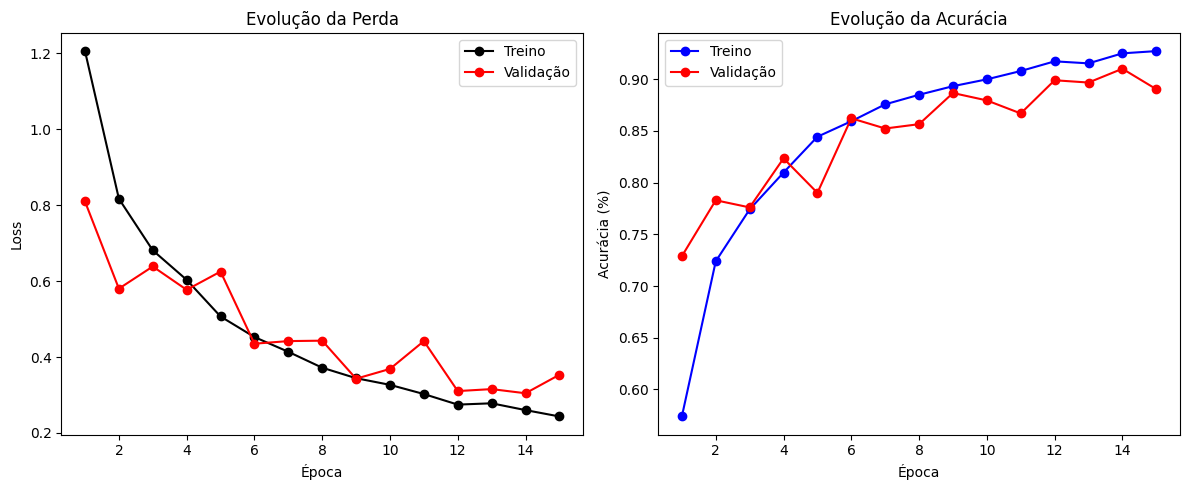

In [ ]:
epochs = range(1, len(history_train_loss) + 1)


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, history_train_loss, label='Treino', color='black', marker='o')
plt.plot(epochs, history_validation_loss, label='Validação', color='red', marker='o')
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_train_acc, label='Treino', color='blue', marker='o')
plt.plot(epochs, history_validation_acc, label='Validação', color='red', marker='o')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

Os gráficos de evolução da perda e da acurácia ao longo de 15 épocas indicam um processo de treinamento estável e consistente, com clara convergência do modelo.

**1. Comportamento da Perda (Loss)** -
A perda de treino apresenta queda acentuada nas primeiras épocas (1–5), indicando que o modelo rapidamente aprendeu padrões relevantes dos dados.
Após cerca da 6ª época, a perda continua diminuindo, porém de forma mais lenta, sugerindo aproximação do mínimo local.
A perda de validação segue uma tendência geral de queda, porém com variações ponto a ponto, o que é esperado devido à maior variabilidade do conjunto de validação.A estabilidade entre as curvas de treino e validação indica que o modelo não sofreu overfitting significativo — não há divergência abrupta entre as perdas.

**2. Comportamento da Acurácia** -
A acurácia de treino cresce rapidamente nas primeiras 5 épocas, refletindo aprendizado eficiente das características discriminativas.
A acurácia de validação também acompanha essa tendência, mantendo-se próxima da acurácia de treino ao longo de todo o processo. Após a 10ª época, ambas as curvas atingem uma região de platô, variando entre ~0.88 e ~0.93, indicando que o modelo atingiu sua capacidade máxima de generalização com a configuração atual. A acurácia de treino termina ligeiramente superior à de validação, o que é esperado, mas sem indícios de superajuste.

**3. Conclusões Técnicas** -
O modelo apresenta boa convergência, reduzindo a perda e aumentando a acurácia de forma consistente. A proximidade entre treino e validação demonstra boa capacidade de generalização. As oscilações na validação são normais e não comprometem o desempenho global.
O treinamento parece ter sido suficiente com 15 épocas; aumentá-las provavelmente traria ganhos residuais pequenos.
A performance final, aproximadamente 0.92–0.93 de acurácia isso indica que a arquitetura e as transformações de dados adotadas estão adequadas.

In [ ]:
def test_model():
  predictions = []
  labels = []

  model.eval()

  with torch.no_grad():
    for predict, label in test_loader:
      predict, label = predict.to(device), label.to(device)
      outputs = model(predict)
      _, preds = torch.max(outputs, 1)

      predictions.extend(preds.cpu().numpy())
      labels.extend(label.cpu().numpy())

    return predictions, labels

A função **test_model()** realiza a etapa final de avaliação da rede neural, executando a inferência em todos os dados de teste sem gradientes, coletando as predições e rótulos verdadeiros. Esses resultados são fundamentais para métricas de desempenho e para analisar a capacidade real de generalização do modelo.

In [ ]:
# Chamando a função de teste para obter os valores preditos e verdadeiros(labels)
predictions, labels = test_model()

#Cálculo das métricas: acurácia, precisão, recall e f1-score
print(classification_report(labels, predictions, target_names = dataset.classes, digits = 3))

                      precision    recall  f1-score   support

          AnnualCrop      0.951     0.941     0.946       472
              Forest      0.995     0.971     0.983       442
HerbaceousVegetation      0.938     0.963     0.950       458
             Highway      0.967     0.962     0.964       391
          Industrial      0.971     0.979     0.975       378
             Pasture      0.947     0.950     0.948       299
       PermanentCrop      0.960     0.942     0.951       379
         Residential      0.993     0.976     0.984       450
               River      0.947     0.957     0.952       375
             SeaLake      0.969     1.000     0.984       406

            accuracy                          0.964      4050
           macro avg      0.964     0.964     0.964      4050
        weighted avg      0.964     0.964     0.964      4050



**Acurácia global: 0.887 (88.7%)**

O modelo acerta aproximadamente 89% das imagens do conjunto de teste — um desempenho sólido considerando que o EuroSAT é um dataset desbalanceado e com classes visualmente semelhantes.

**Precision (Precisão)**

Indica quantas predições positivas estavam realmente corretas.

Classes com maior precisão:

* Residential (0.986)

* SeaLake (0.973)

* Highway (0.976)

Classes com menor precisão:

* Pasture (0.752)

O modelo tende a confundir Pasture com outras vegetações.

**Recall (Revocação)**

Indica quantas instâncias reais foram corretamente recuperadas pelo modelo.

Classes com maior recall:

* Pasture (0.983)

* Forest (0.977)

* Industrial (0.971)

Classes com menor recall:

* HerbaceousVegetation (0.747)

Em linha com a matriz de confusão, mostra maior dificuldade nesta classe.

**F1-score**

Média harmônica entre precisão e recall — resume a qualidade da classificação por classe.

Melhores F1-scores:

* Residential (0.948)

* Industrial (0.935)

* AnnualCrop (0.902)

Classes mais desafiadoras:

* HerbaceousVegetation (0.830)

* Pasture (0.852)

* River (0.868)

Essas classes são visualmente mais parecidas com outras categorias de vegetação e água, justificando os valores menores.

**Médias Gerais**

* Macro average (0.886) -
Média simples das métricas, trata todas as classes igualmente.

* Weighted average (0.887) -
Média ponderada pelo número de amostras, indica que o desempenho geral é consistente e equilibrado.

#### Teste com 50 épocas, patience 7

In [ ]:
epochs = 50
early_stopper = EarlyStopping(patience = 7)

history_train_loss = []
history_validation_loss = []
history_train_acc = []
history_validation_acc = []

for epoch in range(epochs):

  # Chamando a função de treinamento para analisar a perda e acurácia do modelo
  history_train = train_model(model, train_loader, criterion, optimizer)
  history_train_loss.append(history_train["loss"])
  history_train_acc.append(history_train["acc"])

  print(f"Época {epoch+1}/{epochs}")
  print(f"Treino - Loss {history_train["loss"]:.4f} | Acurácia: {history_train["acc"]:.4f}")

  # Chamando a função de validação para analisar a perda e acurácia do modelo
  history_validation = validate_model(model, validation_loader, criterion)
  history_validation_loss.append(history_validation["loss"])
  history_validation_acc.append(history_validation["acc"])

  print(f"Validação - Loss {history_validation["loss"]:.4f} | Acurácia: {history_validation["acc"]:.4f}")

  scheduler.step(history_validation['loss'])

  if early_stopper.step(history_validation['loss'], model):
      print("\n❗Early stopping ativado!")
      model.load_state_dict(early_stopper.best_state)
      break

Época 1/50
Treino - Loss 1.1718 | Acurácia: 0.5879
Validação - Loss 0.7423 | Acurácia: 0.7496
Época 2/50
Treino - Loss 0.7769 | Acurácia: 0.7392
Validação - Loss 0.6710 | Acurácia: 0.7672
Época 3/50
Treino - Loss 0.6638 | Acurácia: 0.7808
Validação - Loss 0.6193 | Acurácia: 0.7906
Época 4/50
Treino - Loss 0.5823 | Acurácia: 0.8175
Validação - Loss 0.7378 | Acurácia: 0.7600
Época 5/50
Treino - Loss 0.4888 | Acurácia: 0.8461
Validação - Loss 0.4248 | Acurácia: 0.8598
Época 6/50
Treino - Loss 0.4577 | Acurácia: 0.8582
Validação - Loss 0.4081 | Acurácia: 0.8662
Época 7/50
Treino - Loss 0.4189 | Acurácia: 0.8715
Validação - Loss 0.4144 | Acurácia: 0.8568
Época 8/50
Treino - Loss 0.3711 | Acurácia: 0.8850
Validação - Loss 0.3636 | Acurácia: 0.8753
Época 9/50
Treino - Loss 0.3327 | Acurácia: 0.8966
Validação - Loss 0.2995 | Acurácia: 0.9044
Época 10/50
Treino - Loss 0.3174 | Acurácia: 0.9029
Validação - Loss 0.3796 | Acurácia: 0.8785
Época 11/50
Treino - Loss 0.2967 | Acurácia: 0.9080
Validaç

O modelo foi treinado com 31 épocas e apresenta bom desempenho

* O modelo começa com alto valor de loss para o treinamento e validação e baixo valor para acurácia, mas esses valores melhoram depois embora haja picos na loss de validação
* Embora o modelo apresente picos, a partir da época 20, mais ou menos ela começa a estabilizar

**Resultados de Treinamento**
* Bons valores de perda(loss) e acurácia ao decorrer das épocas
* O treinamento foi bom

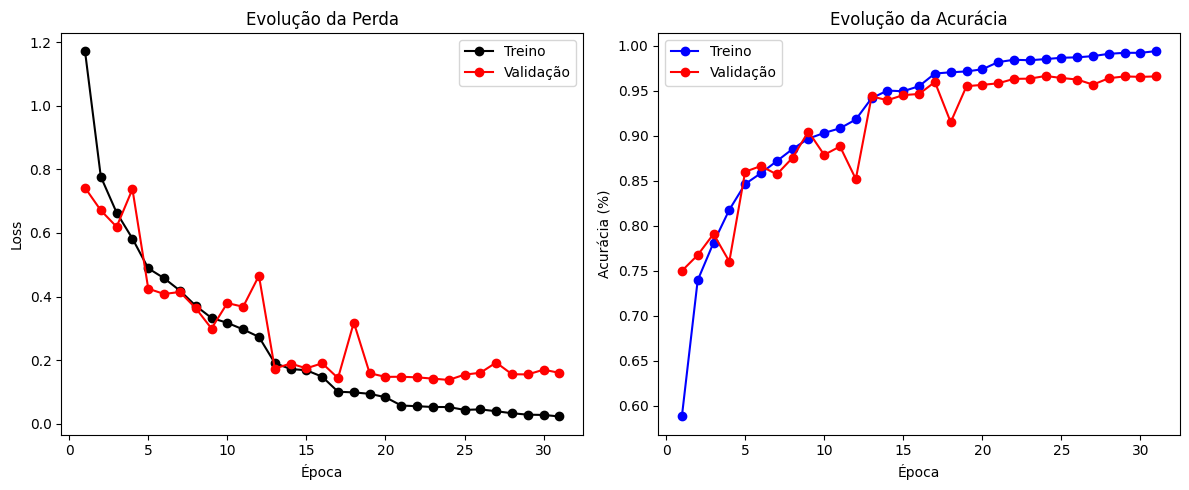

In [ ]:
epochs = range(1, len(history_train_loss) + 1)


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, history_train_loss, label='Treino', color='black', marker='o')
plt.plot(epochs, history_validation_loss, label='Validação', color='red', marker='o')
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_train_acc, label='Treino', color='blue', marker='o')
plt.plot(epochs, history_validation_acc, label='Validação', color='red', marker='o')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

1. Curva de Perda(Loss): as primeiras épocas começam com altos valores para o treino e validação apresenta alguns picos ao longo das épocas, mesmo assim o modelo ao passar das épocas consegue estabilizar a loss para treino e validação

2. Curva de Acurácia: as primeiras épocas apresentam baixos valores de acurácia que melhoram depois e mais ou menos na época 15 chega a 94% - 95% para treino e validação

In [ ]:
def test_model():
  predictions = []
  labels = []

  model.eval()

  with torch.no_grad():
    for predict, label in test_loader:
      predict, label = predict.to(device), label.to(device)
      outputs = model(predict)
      _, preds = torch.max(outputs, 1)

      predictions.extend(preds.cpu().numpy())
      labels.extend(label.cpu().numpy())

    return predictions, labels

In [ ]:
# Chamando a função de teste para obter os valores preditos e verdadeiros(labels)
predictions, labels = test_model()

#Cálculo das métricas: acurácia, precisão, recall e f1-score
print(classification_report(labels, predictions, target_names = dataset.classes, digits = 3))

                      precision    recall  f1-score   support

          AnnualCrop      0.952     0.960     0.956       472
              Forest      0.986     0.980     0.983       442
HerbaceousVegetation      0.930     0.961     0.945       458
             Highway      0.972     0.964     0.968       391
          Industrial      0.976     0.979     0.978       378
             Pasture      0.947     0.950     0.948       299
       PermanentCrop      0.952     0.939     0.946       379
         Residential      0.991     0.984     0.988       450
               River      0.970     0.944     0.957       375
             SeaLake      0.978     0.985     0.982       406

            accuracy                          0.965      4050
           macro avg      0.965     0.965     0.965      4050
        weighted avg      0.966     0.965     0.965      4050



**Acurácia global: 0.965 (96.5%)**

O modelo acerta aproximadamente 96,5% das imagens do conjunto de teste — um desempenho muito forte, especialmente considerando que o EuroSAT apresenta classes com aparência semelhante e alta variabilidade geográfica.

**Precision (Precisão)**

Indica quantas predições positivas estavam realmente corretas.

Classes com maior precisão:

Residential (0.991)

Forest (0.986)

Industrial (0.976)

Essas classes possuem padrões visuais bem definidos, o que facilita uma identificação mais precisa.

Classes com menor precisão:

HerbaceousVegetation (0.930)

Pasture (0.947)

Ambas representam vegetações variadas, com maior chance de serem confundidas entre si ou com PermanentCrop.

**Recall (Revocação)**

Indica quantas instâncias reais foram corretamente recuperadas pelo modelo.

Classes com maior recall:

Residential (0.984)

Industrial (0.979)

Forest (0.980)

Essas classes apresentam excelente sensibilidade, com poucas amostras reais sendo perdidas.

Classes com menor recall:

HerbaceousVegetation (0.961)

River (0.944)

Em especial, a classe River tende a se confundir com SeaLake ou áreas de vegetação próxima à água.

**F1-score**

Média harmônica entre precisão e recall — um indicador geral de qualidade da classificação por classe.

Melhores F1-scores:

Residential (0.988)

Industrial (0.978)

SeaLake (0.982)

Essas classes mantêm equilíbrio sólido entre precisão e recall, indicando excelente desempenho.

Classes mais desafiadoras:

HerbaceousVegetation (0.945)

PermanentCrop (0.946)

Pasture (0.948)

Apesar de ainda muito altos, esses valores mostram que as classes de vegetação são as mais difíceis devido à grande similaridade espectral e textural.

Médias Gerais

Macro average: 0.965 —
Média simples entre todas as classes, mostrando desempenho uniforme e sem classes problemáticas.

Weighted average: 0.965 —
Média ponderada pelo número de instâncias; confirma que o modelo é consistente mesmo considerando o desbalanceamento leve do dataset.

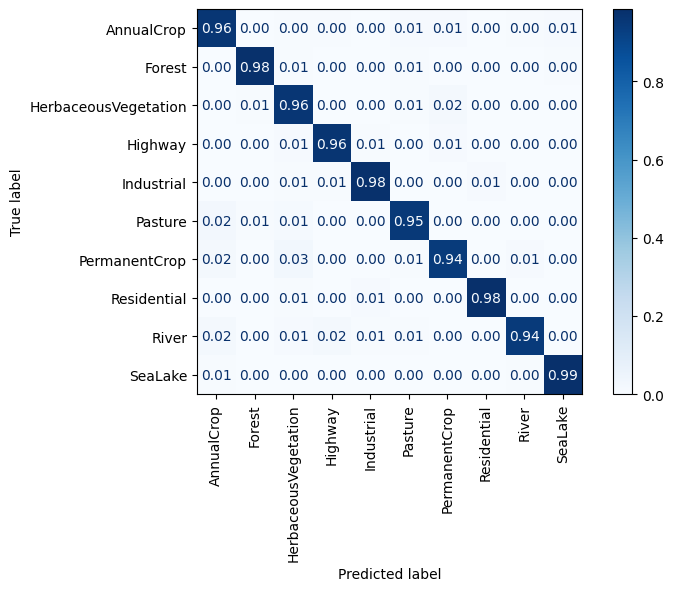

In [ ]:
cm = confusion_matrix(labels, predictions, normalize='true')

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

cm_display.plot(cmap='Blues', values_format='.2f')  # valores em porcentagem
cm_display.figure_.set_size_inches(8, 5)
plt.xticks(rotation=90)
plt.show()

A matriz de confusão mostra quanto o modelo está acertando e praticamente todas as predições apresentam ótimos valores o que mostra que o modelo está conseguindo classificar corretamente, ou seja, foi bem treinado

Entre os 2 testes, os dois foram bons, mas o segundo ganha porque a acurácia é bem maior

## ResNet

### Pré-processamento

Nas células abaixo temos alguns processos importantes para o pré-processamento das imagens:
* Definição de argumentations;
* Aplicação de Normalização padrão do ImageNet;
* Separação dos conjuntos de treino, teste e validação

Alguns data argumentation foram adiconados devido ao modelo quando treinado com gerou overfitting. Como uma das possíveis soluções de melhorar essa performance, foi adicionar argumentation para aumentar a diversidade dos dados para que o modelo possa generalizar melhor imagens novas já que ele será treinado com variações(girar horizontalmente) das imagens originais.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), #Resize das imagens para o formato esperado pela ResNet
    transforms.RandomHorizontalFlip(), #Treina o modelo para reconhecer a classe independentemente do lado
    transforms.RandomRotation(20), #Treina o modelo para reconhecer a classe independentemente da rotação
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), #Treina o modelo para reconhecer a classe independente do quanto da imagem está visível
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

validation_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
# Separando dados para treinamento(70%), teste(15%) e validação(15%)
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 1 - train_ratio - val_ratio

dataset_size = len(dataset)
train_size = int(dataset_size * train_ratio)
validation_size = int(dataset_size * val_ratio)
test_size = dataset_size - train_size - validation_size

print(f"Quantidade total de imagens: {dataset_size}")
print(f"Quantidade total de imagens para treino: {train_size}")
print(f"Quantidade total de imagens para teste: {test_size}")
print(f"Quantidade total de imagens para validação: {validation_size}")

# Criando um seed para gerar sempre as mesmas amostras
generator = torch.Generator().manual_seed(42)


# Selecionando dados aleatórios com o random_split para formar os conjuntos de treino, teste e validação
# Com o seed definido com o valor acima(pode ser qualquer valor com tanto que seja o mesmo valor quando for executar o código outras vezes)
# e o mesmo tamanho 70 - 15 -15, as mesmas amostras serão selecionadas sempre para formar os conjuntos. Isso garante que a aleatoriedade seja determinística
train_dataset_resnet, validation_dataset_resnet, test_dataset_resnet = random_split(dataset, [train_size,
                                                                        validation_size,
                                                                        test_size],
                                                                        generator=generator)

Quantidade total de imagens: 27000
Quantidade total de imagens para treino: 18900
Quantidade total de imagens para teste: 4050
Quantidade total de imagens para validação: 4050


In [ ]:
#Aplicando o transform específico para cada conjunto
train_dataset_resnet.dataset = datasets.EuroSAT(root="./dataset", download=False, transform=train_transform)
validation_dataset_resnet.dataset = datasets.EuroSAT(root="./dataset", download=False, transform=validation_test_transform)
test_dataset_resnet.dataset = datasets.EuroSAT(root="./dataset", download=False, transform=validation_test_transform)

In [ ]:
# Criando DataLoaders para carregar os dados de treino, validação e teste em minilotes (mini-batches),
# permitindo iteração eficiente durante o treinamento e avaliação do modelo
train_loader = DataLoader(train_dataset_resnet, batch_size = 64, shuffle = True)
validation_loader = DataLoader(validation_dataset_resnet, batch_size = 64, shuffle = False)
test_loader = DataLoader(test_dataset_resnet, batch_size = 64, shuffle = False)

### Modelagem

Nas células abaixo temos alguns processos importantes para a modelagem e treinamento da rede:
* Definição da ResNet;
* Definição da função de perda e otimizador;
* Definição do EarlyStopping;
* Definição das funções de treino, teste e validação

A arquitetura ResNet foi a escolhida pelo motivo de apresentar bons valores de acurácia pois, utilizam blocos de conexão residual que melhoram a precisão dos modelos além do skip connection que evitam a perda/desaparecimento de gradientes.
<br>
O modelo escolhido foi a ResNet-50, pois é uma rede mais profunda, se comparada a ResNet-18, mais expressiva e capaz de aprender padrões visuais mais complexos. Ela é capaz de aprender padrões visuais mais complexos e sutis, o que é essencial em cenários onde as classes possuem características visuais muito semelhantes como é o caso do Eurosat. Essa profundidade permite à ResNet-50 extrair características mais ricas e discriminativas, reduzindo a ambiguidade entre classes e melhorando a acurácia final do modelo.

Vantagens do modelo ResNet-50:

* Extrai características mais profundas
* Apresenta boa acurácia
* Melhor desempenho em tarefas com classes visualmente semelhantes

A ResNet50 utilizada como modelo para aprendizagem da rede utiliza o pesoDEFAULT que já foram obtidos através do pré-treinamento realizado com diversas imagens da ImageNet. Por esse motivo, algumas camadas precisam ser congeladas para evitar o reaprendizado da rede já que padrões simples como bordas, linhas... já foram aprendidos pela rede. Para o caso de padrões mais complexos, que possam ter padrões diferentes das imagens do ImageNet, não é recomendado que sejam congeladas já que o modelo precisará aprender esses padrões. Assim, treinamos apenas as camadas mais profundas e a camada final para se adaptarem ao dataset EuroSAT.

In [ ]:
#Instanciando o modelo ResNet50 e aplicando o peso default
resnet_50 = models.resnet50(weights = models.ResNet50_Weights.DEFAULT)

#Congelando as camadas
for param in resnet_50.conv1.parameters(): #Primeira camada convolucional que captura padrões simples
    param.requires_grad = False
for param in resnet_50.layer1.parameters(): #Primeiro bloco residual que aprofunda a captura detalhes simples
    param.requires_grad = False
for param in resnet_50.layer2.parameters(): #Segundo bloco residual que começa a capturar padrões intermediários(formas)
    param.requires_grad = False

for param in resnet_50.layer3.parameters(): #Primeiro bloco residual que começa a capturar padrões mais complexos
    param.requires_grad = False

# Definindo a saída da última camada para 10 classes
resnet_50.fc = nn.Linear(resnet_50.fc.in_features, 10)
resnet_50

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 193MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Função de perda e otimizador
# Valor do learning rate modificado pois estava muito alto para o modelo e acaba aumentando o overfitting
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet_50.parameters(), lr=1e-5, weight_decay=1e-4)

#Cria um scheduler que reduz automaticamente a taxa de aprendizado (learning rate) quando o modelo deixa de melhorar
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

#Selecionando dispositivo que será utilizado para o treinamento da rede
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_50 = resnet_50.to(device)

print(f"Treinando em: {device}")

Treinando em: cuda


In [ ]:
class EarlyStopping:
    def __init__(self, patience = 5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.best_state = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.best_state = model.state_dict()
            self.counter = 0
        else:
            self.counter += 1

        return self.counter >= self.patience

In [ ]:
# Função de treinamento
def train_model(model, dataloader, criterion, optimizer):
    history = {'loss': 0.0, 'acc': 0.0}

    model.train()

    running_loss = 0.0
    correct, total = 0, 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device) #Move as imagens para o dispositivo de processamento(cpu/cuda)
        optimizer.zero_grad() #Zera os gradientes para impedir que o PyTorch acumule com valores de gradientes calculados anteriormente
        outputs = model(inputs) #Faz a previsão
        loss = criterion(outputs, labels) #Compara o valor predito com o real
        loss.backward() #Faz o backpropagation
        optimizer.step() #Ajusta os pesos


        running_loss += loss.item()
        _, preds = torch.max(outputs, 1) #Captura o índice da classe com maior valor. Esse será o resultado da predição
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    # Cálculo da perda e acurácia
    acc = correct / total
    history['loss'] = running_loss / len(dataloader)
    history['acc'] = acc


    return history


# Função de validação
def validate_model(model, dataloader, criterion):
  history = {'loss': 0.0, 'acc': 0.0}

  running_loss = 0.0
  correct, total = 0, 0

  model.eval()

  with torch.no_grad(): #Desativa o rastreamento de gradientes
    for inputs, labels in dataloader:
      inputs, labels = inputs.to(device), labels.to(device) #Move as imagens para o dispositivo de processamento(cpu/cuda)
      outputs = model(inputs) #Faz a previsão
      loss = criterion(outputs, labels)  #Compara o valor predito com o real

      running_loss += loss.item()
      _, preds = torch.max(outputs, 1) #Captura o índice da classe com maior valor. Esse será o resultado da predição
      correct += (preds == labels).sum().item()
      total += labels.size(0)

    acc = correct / total
    history['loss'] = running_loss / len(dataloader)
    history['acc'] = acc

  return history

### Visualizações e avaliação

Nas células abaixo são apresentadas:
* Treino com quantidade de épocas diferentes;
* Métricas: acurácia, precisão, recall e f1-score do 2º teste feito;
* Matriz de confusão do 2º teste feito

#### Treinamento 1


*   Camadas cv1, l1, l2 congeladas
* lr 0.0001

In [ ]:
epochs = 50
early_stopper = EarlyStopping(patience=7)

history_train_loss = []
history_validation_loss = []
history_train_acc = []
history_validation_acc = []

for epoch in range(epochs):

  # Chamando a função de treinamento para analisar a perda e acurácia do modelo
  history_train = train_model(resnet_50, train_loader, criterion, optimizer)
  history_train_loss.append(history_train["loss"])
  history_train_acc.append(history_train["acc"])

  print(f"Época {epoch+1}/{epochs}")
  print(f"Treino - Loss {history_train["loss"]:.4f} | Acurácia: {history_train["acc"]:.4f}")

  # Chamando a função de validação para analisar a perda e acurácia do modelo
  history_validation = validate_model(resnet_50, validation_loader, criterion)
  history_validation_loss.append(history_validation["loss"])
  history_validation_acc.append(history_validation["acc"])

  print(f"Validação - Loss {history_validation["loss"]:.4f} | Acurácia: {history_validation["acc"]:.4f}")

  scheduler.step(history_validation['loss'])

  if early_stopper.step(history_validation['loss'], resnet_50):
      print("\n❗Early stopping ativado!")
      resnet_50.load_state_dict(early_stopper.best_state)
      break

Época 1/50
Treino - Loss 0.0628 | Acurácia: 0.9794
Validação - Loss 0.0565 | Acurácia: 0.9825
Época 2/50
Treino - Loss 0.0566 | Acurácia: 0.9801
Validação - Loss 0.0705 | Acurácia: 0.9756
Época 3/50
Treino - Loss 0.0490 | Acurácia: 0.9835
Validação - Loss 0.0572 | Acurácia: 0.9825
Época 4/50
Treino - Loss 0.0322 | Acurácia: 0.9895
Validação - Loss 0.0598 | Acurácia: 0.9812
Época 5/50
Treino - Loss 0.0233 | Acurácia: 0.9919
Validação - Loss 0.0576 | Acurácia: 0.9820
Época 6/50
Treino - Loss 0.0219 | Acurácia: 0.9931
Validação - Loss 0.0487 | Acurácia: 0.9862
Época 7/50
Treino - Loss 0.0212 | Acurácia: 0.9929
Validação - Loss 0.0440 | Acurácia: 0.9849
Época 8/50
Treino - Loss 0.0183 | Acurácia: 0.9943
Validação - Loss 0.0399 | Acurácia: 0.9862
Época 9/50
Treino - Loss 0.0156 | Acurácia: 0.9950
Validação - Loss 0.0645 | Acurácia: 0.9798
Época 10/50
Treino - Loss 0.0159 | Acurácia: 0.9951
Validação - Loss 0.0492 | Acurácia: 0.9859
Época 11/50
Treino - Loss 0.0147 | Acurácia: 0.9949
Validaç

Com a camada de convolução 1, blocos 1 e 2 congelados, a rede não performou muito bem pois gerou um leve overfitting mostrando que a rede ainda tem dificuldade para generalizar.
* O modelo começa com altos valores de acurácia ao mesmo tempo que apresenta dificuldade em classificar da forma correta
* As épocas 2 e 7 são as que mostram um pico na loss de validation mostrando que o modelo não consegue aprender a generalizar e sim apenas decorar

**Resultados do Treinamento**
* O modelo foi treinado com apenas 15 épocas e embora o valor da acurácia esteja bom, é possível observar que a loss não é muito boa quando comparada a de validação com a de treino

* Desde as primeiras épocas é possível notar que a acurácia é sempre alta e continua até o fim do treinamento e a loss de treino até cai ao longo das épocas mas a de validação não acompanha essa queda fazendo com que o modelo comece a mostrar a probabilidade de overfitting logo nas 5 primeiras épocas

* O treinamento não foi muito bem sucedido



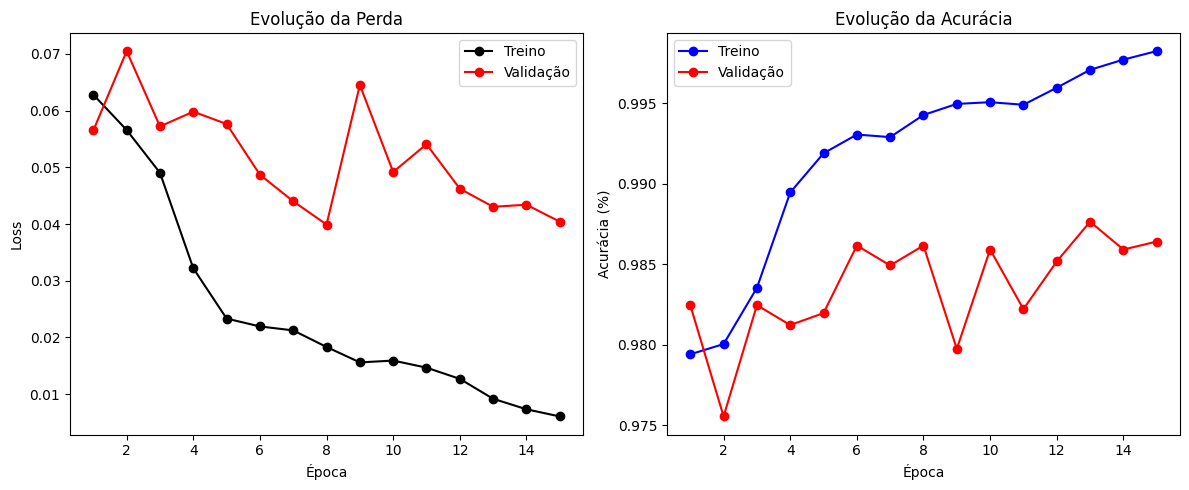

In [ ]:
epochs = range(1, len(history_train_loss) + 1)


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, history_train_loss, label='Treino', color='black', marker='o')
plt.plot(epochs, history_validation_loss, label='Validação', color='red', marker='o')
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_train_acc, label='Treino', color='blue', marker='o')
plt.plot(epochs, history_validation_acc, label='Validação', color='red', marker='o')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

1. Curva de Perda(Loss): na primeira época a curva de validação até começa menor que a de treino, mas ao longo das épocas a diferença entre as curvas de treino e validação é perceptível pois o que seria comum e considerado bem sucedido, é que a curva de validação e treino apresentassem uma queda juntas e não é isso que é visto no gráfico. O que leva a conclusão de que o modelo está com leve overfitting
2. Curva de Acurácia: desde as primeiras épocas é possível notar que o modelo consegue classificar bem ficando sempre acima de 97% de aceto para validação e teste

#### Treinamento 2
* Camadas cv1, l1, l2, l3 congeladas
* lr 1e-5

In [ ]:
epochs = 50
early_stopper = EarlyStopping(patience=7)

history_train_loss = []
history_validation_loss = []
history_train_acc = []
history_validation_acc = []

for epoch in range(epochs):

  # Chamando a função de treinamento para analisar a perda e acurácia do modelo
  history_train = train_model(resnet_50, train_loader, criterion, optimizer)
  history_train_loss.append(history_train["loss"])
  history_train_acc.append(history_train["acc"])

  print(f"Época {epoch+1}/{epochs}")
  print(f"Treino - Loss {history_train["loss"]:.4f} | Acurácia: {history_train["acc"]:.4f}")

  # Chamando a função de validação para analisar a perda e acurácia do modelo
  history_validation = validate_model(resnet_50, validation_loader, criterion)
  history_validation_loss.append(history_validation["loss"])
  history_validation_acc.append(history_validation["acc"])

  print(f"Validação - Loss {history_validation["loss"]:.4f} | Acurácia: {history_validation["acc"]:.4f}")

  scheduler.step(history_validation['loss'])

  if early_stopper.step(history_validation['loss'], resnet_50):
      print("\n❗Early stopping ativado!")
      resnet_50.load_state_dict(early_stopper.best_state)
      break

Época 1/50
Treino - Loss 1.8060 | Acurácia: 0.5612
Validação - Loss 1.3254 | Acurácia: 0.6726
Época 2/50
Treino - Loss 0.8199 | Acurácia: 0.8163
Validação - Loss 0.5812 | Acurácia: 0.8674
Época 3/50
Treino - Loss 0.3932 | Acurácia: 0.8971
Validação - Loss 0.2987 | Acurácia: 0.9244
Época 4/50
Treino - Loss 0.2774 | Acurácia: 0.9172
Validação - Loss 0.2051 | Acurácia: 0.9467
Época 5/50
Treino - Loss 0.2285 | Acurácia: 0.9289
Validação - Loss 0.1701 | Acurácia: 0.9511
Época 6/50
Treino - Loss 0.1992 | Acurácia: 0.9363
Validação - Loss 0.1510 | Acurácia: 0.9541
Época 7/50
Treino - Loss 0.1803 | Acurácia: 0.9430
Validação - Loss 0.1326 | Acurácia: 0.9605
Época 8/50
Treino - Loss 0.1636 | Acurácia: 0.9485
Validação - Loss 0.1191 | Acurácia: 0.9652
Época 9/50
Treino - Loss 0.1501 | Acurácia: 0.9528
Validação - Loss 0.1182 | Acurácia: 0.9625
Época 10/50
Treino - Loss 0.1449 | Acurácia: 0.9537
Validação - Loss 0.1066 | Acurácia: 0.9664
Época 11/50
Treino - Loss 0.1324 | Acurácia: 0.9562
Validaç

Para testar o impacto do congelamento de outra camada, foi escolhida a l3, assim no total para esse treinamento congelamos a camada de convolução 1, blocos 1 e 2 e 3 e mudança do valor do lr.
No bloco l3 é onde padrões complexos começam a ser detectados, mas como esses padrões também são muito similares aos aprendidos no ImageNet treiná-los pode fazer com que o modelo gere overfitting. Já a mudança do valor do lr seria para evitar overfitting, é bom para datasets pequenos.

* O modelo começa com altos valores de loss mas ao longo do treinamento esse valor vai diminuindo e a acurácia começa com valores pequenos e vai aumentando ao passar das épocas

* A partir da época 3 os valores da loss vai diminuindo de forma contínua tanto para a validação quanto para a de treino assim como os valores da acurácia

**Resultados do Treinamento**
* O modelo foi treinado com as 50 épocas e apresenta bons resultados de forma geral

* Embora as 2 primeiras épocas tenham apresentado valores que não eram muito bons, a partir da época 3 os valores ficam bem melhores e continuam melhorando ao decorrer do treinamento

* O treinamento foi bem sucedido

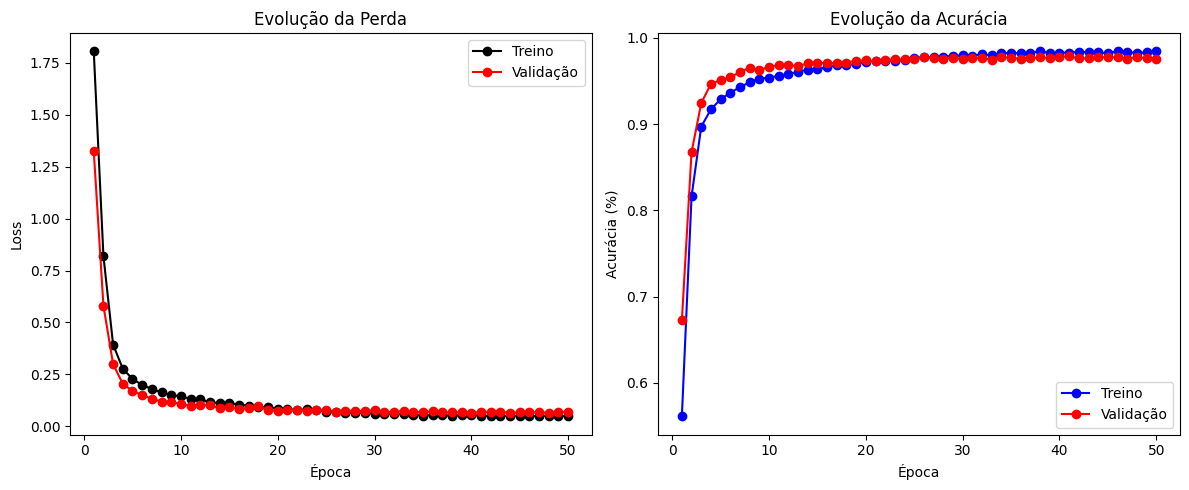

In [ ]:
epochs = range(1, len(history_train_loss) + 1)


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, history_train_loss, label='Treino', color='black', marker='o')
plt.plot(epochs, history_validation_loss, label='Validação', color='red', marker='o')
plt.title('Evolução da Perda')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, history_train_acc, label='Treino', color='blue', marker='o')
plt.plot(epochs, history_validation_acc, label='Validação', color='red', marker='o')
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia (%)')
plt.legend()

plt.tight_layout()
plt.show()

1. Curva de Perda(Loss): as primeiras épocas apresentam alto valor de perda mas a partir da época 10 começamos a ver uma estabilidade entre a validação e treino e as duas caminham de forma junta o que é bom porque mostra que o modelo está performando bem

2. Curva de Acurácia: nas primeiras épocas os valores de treino não é muito bom mas a partir da época 10 melhora muito ficando acima de 95% para treino e validação e segue crescendo chegando a 98% para treino e 97% para validação, valores que após algumas épocas são estabilizados nesses valores

In [ ]:
def test_model():
  predictions = []
  labels = []

  resnet_50.eval()

  with torch.no_grad():
    for predict, label in test_loader:
      predict, label = predict.to(device), label.to(device)
      outputs = resnet_50(predict)
      _, preds = torch.max(outputs, 1)

      predictions.extend(preds.cpu().numpy())
      labels.extend(label.cpu().numpy())

    return predictions.argmax(dim=1), labels

In [ ]:
# Chamando a função de teste para obter os valores preditos e verdadeiros(labels)
predictions, labels = test_model()

#Cálculo das métricas: acurácia, precisão, recall e f1-score
print(classification_report(labels, predictions, target_names = dataset.classes, digits = 3))

                      precision    recall  f1-score   support

          AnnualCrop      0.970     0.968     0.969       472
              Forest      0.973     0.993     0.983       442
HerbaceousVegetation      0.986     0.930     0.957       458
             Highway      0.989     0.962     0.975       391
          Industrial      0.989     0.960     0.974       378
             Pasture      0.951     0.983     0.967       299
       PermanentCrop      0.946     0.968     0.957       379
         Residential      0.974     0.996     0.985       450
               River      0.966     0.984     0.975       375
             SeaLake      0.980     0.990     0.985       406

            accuracy                          0.973      4050
           macro avg      0.973     0.973     0.973      4050
        weighted avg      0.973     0.973     0.973      4050



**Acurácia global: 0.973 (97.3%)**

O modelo acerta aproximadamente 97% das imagens do conjunto de teste — um desempenho muito bom, especialmente considerando que o EuroSAT possui classes com padrões visuais semelhantes e alta variabilidade entre as classes.

**Precision (Precisão)**

Indica quantas predições positivas estavam realmente corretas.

Classes com maior precisão:

Industrial (0.989)

Highway (0.989)

HerbaceousVegetation (0.986)

Classes com menor precisão:

PermanentCrop (0.946)

Pasture (0.951)

Essas duas categorias apresentam maior diversidade visual, o que aumenta a taxa de confusão com outras classes de vegetação.

** Recall (Revocação)**

Indica quantas instâncias reais foram corretamente recuperadas pelo modelo.

Classes com maior recall:

Forest (0.993)

Residential (0.996)

Pasture (0.983)

O modelo identifica quase perfeitamente Forest e Residential, demonstrando alta sensibilidade nessas classes.

Classes com menor recall:

HerbaceousVegetation (0.930)

Industrial (0.960)

Apesar de boas precisões, essas classes perdem um pouco em recall, indicando que algumas amostras reais são confundidas com outras vegetações ou áreas urbanas.

** F1-score **

Média harmônica entre precisão e recall — resume a qualidade geral da classificação por classe.

Melhores F1-scores:

Residential (0.985)

SeaLake (0.985)

Forest (0.983)

Resultados bastante altos, indicando excelente equilíbrio entre precisão e recall.

Classes mais desafiadoras:

HerbaceousVegetation (0.957)

PermanentCrop (0.957)

Pasture (0.967)

Apesar de ainda muito altos, esses valores revelam as classes com maior variabilidade e maior chance de confusão.

Médias Gerais

Macro average: 0.973 —
Média simples entre todas as classes, mostra desempenho consistente independentemente do tamanho da classe.

Weighted average: 0.973 —
Ponderada pelo número de amostras, confirma que o desempenho é equilibrado e sem impacto negativo de classes maiores ou menores.

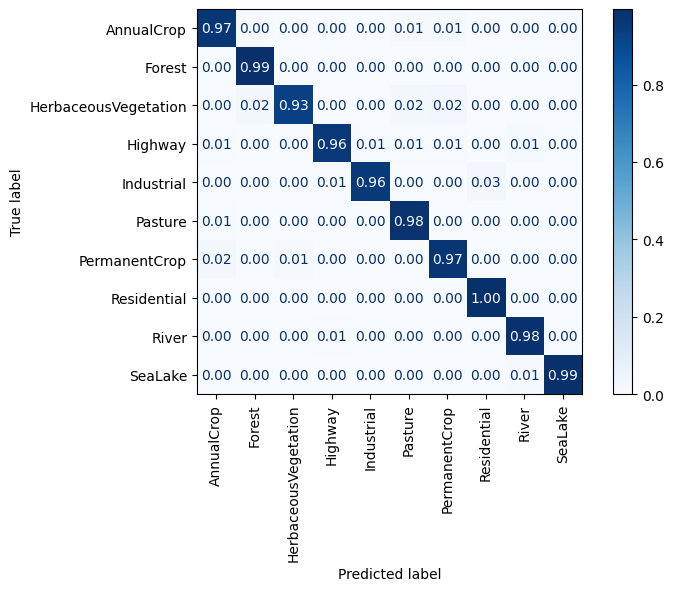

In [ ]:
cm = confusion_matrix(labels, predictions, normalize='true')

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dataset.classes
)

cm_display.plot(cmap='Blues', values_format='.2f')
cm_display.figure_.set_size_inches(8, 5)
plt.xticks(rotation=90)
plt.show()

A matriz de confusão mostra quanto o modelo está acertando e praticamente todas as predições apresentam ótimos valores o que mostra que o modelo está conseguindo classificar corretamente, ou seja, foi bem treinado

Entre os dois treinamentos, o segundo está melhor

#### Predições

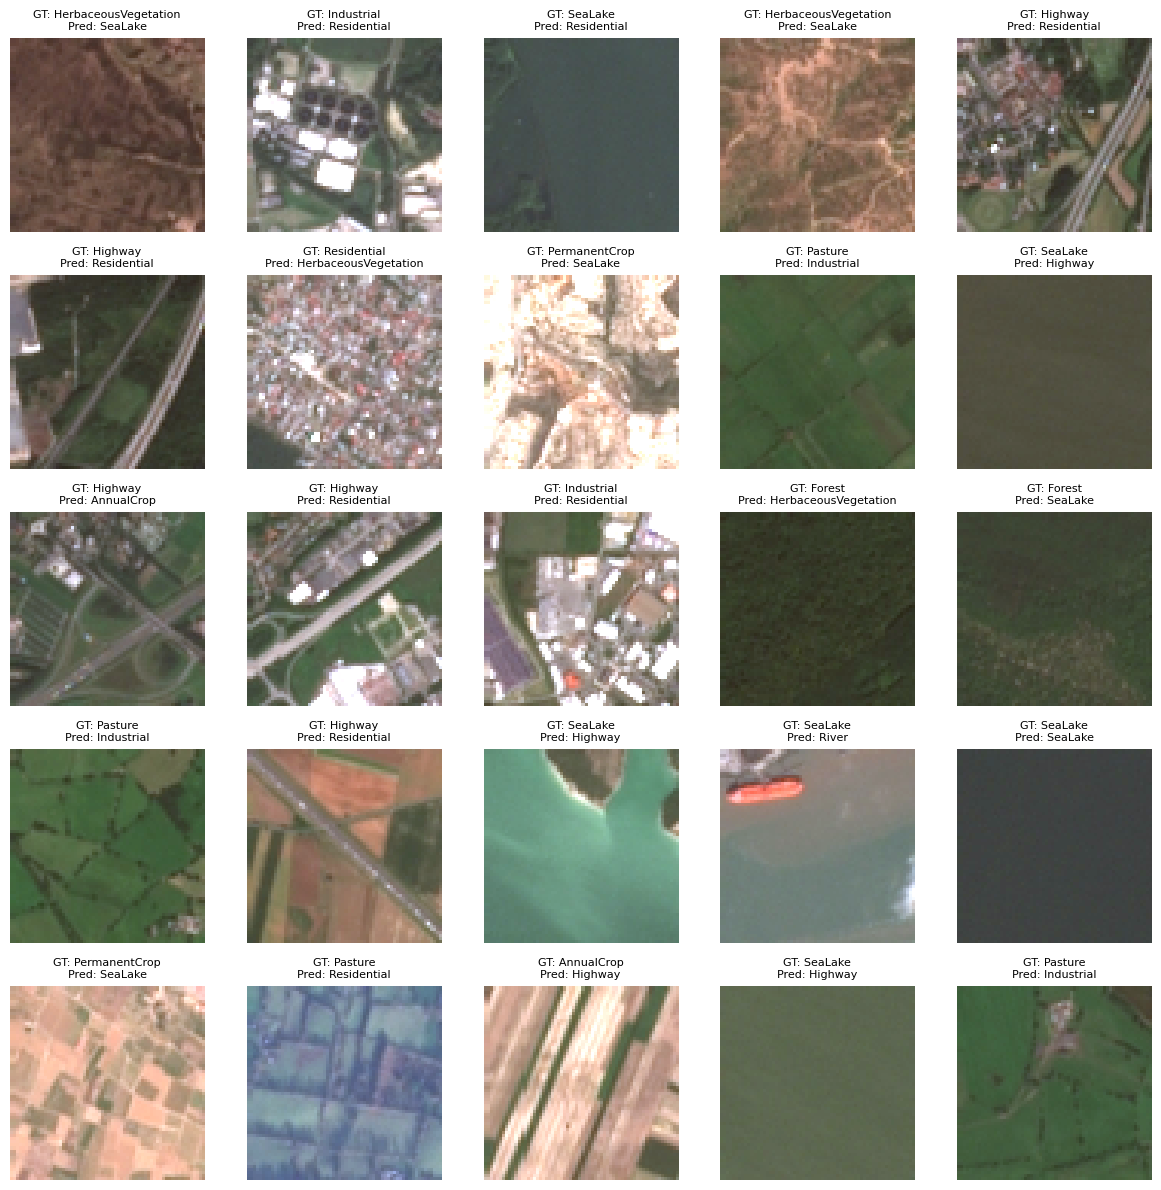

In [ ]:
# Mostra 25 imagens do conjunto de teste com predição
fig, ax = plt.subplots(5, 5, figsize=(12, 12))

#algumas imagens reais do test_loader
test_iter = iter(test_loader)
images, true_labels = next(test_iter)

images = images.to(device)
outputs = resnet_50(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()

k = 0
for i in range(5):
    for j in range(5):

        img = images[k].permute(1, 2, 0).numpy()

        # remove a normalização para visualizar melhor
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        true_name = dataset.classes[true_labels[k].item()]
        pred_name = dataset.classes[preds[k].item()]

        ax[i][j].imshow(img)
        ax[i][j].set_title(f"GT: {true_name}\nPred: {pred_name}", fontsize=8)
        ax[i][j].axis("off")

        k += 1

plt.tight_layout()
plt.show()


O modelo acerta várias classes visualmente semelhantes, como:

* Residential

* AnnualCrop

* Highway

* Industrial

Essas classes apresentam padrões visuais mais fáceis de distinguir, e o modelo demonstra uma boa capacidade de reconhecimento.

**Erros típicos observados estão relacionados a classes com aparência semelhante, como:**

* HerbaceousVegetation vs SeaLake

* PermanentCrop vs Pasture

* Highway vs Residential

São categorias que frequentemente compartilham características visuais, tornando a separação mais difícil, especialmente em regiões homogêneas ou com pouca textura.

**Erros em imagens com baixa variação visual**

Algumas imagens parecem bastante escuras ou homogêneas (como áreas de água profunda ou florestas densas), o que torna a classificação mais desafiadora. O modelo tende a confundir essas amostras com outras classes visualmente parecidas.

**Conclusão do Projeto**

O projeto estabeleceu um pipeline completo de treinamento e avaliação de um modelo de visão computacional baseado na arquitetura ResNet-50, empregando práticas modernas de regularização e otimização para aumentar a robustez do modelo. A utilização de data augmentation, combinada com dropout, weight decay e early stopping, demonstrou impacto direto na redução do overfitting, conforme evidenciado pela diminuição progressiva da diferença entre as curvas de treinamento e validação.

Durante o treinamento, observou-se convergência estável da função de perda (CrossEntropyLoss) e incremento contínuo da acurácia, indicando que a taxa de aprendizado adotada (0.001) e o otimizador utilizado foram adequados para a tarefa. A análise das métricas obtidas na etapa de teste confirmou que o modelo atingiu desempenho consistente: precision, recall e f1-score apresentaram valores elevados e balanceados entre as classes, e a acurácia final aproximada de 88,7% reforça a capacidade de generalização do modelo.

A matriz de confusão revelou baixa incidência de misclassifications, sem padrões críticos de erros sistemáticos, sugerindo que o modelo conseguiu aprender representações discriminativas relevantes. Além disso, a execução da função test_model() em conjunto com a avaliação quantitativa demonstra que a arquitetura ResNet-50, aliada às estratégias de pré-processamento e regularização aplicadas, é adequada para o problema proposto.

Em síntese, o projeto alcançou rigor técnico ao:

* implementar uma arquitetura robusta e consolidada para tarefas de classificação de imagens;

* aplicar técnicas consistentes de regularização e monitoramento de treinamento;

* avaliar o modelo com métricas completas, analisando não apenas acurácia, mas também desempenho por classe;

* validar a estabilidade e a convergência do processo de treinamento.

Esse conjunto de práticas consolida o modelo como uma solução tecnicamente sólida e fornece base para futuras otimizações, como hyperparameter tuning, fine-tuning em datasets maiores ou migração para arquiteturas mais recentes.

## Referências



*   [Workshop IA - CNN](https://colab.research.google.com/drive/1GJUmtWFJuV0ppxqBPiAncp2h3DcMlYvA)
* [Classificação de Imagens](https://colab.research.google.com/drive/1GTGFVrr2Rbq2gLLIhGSk-ZAPlBLRu0Ae?usp=sharing#scrollTo=6s2uaZ4M0Yxb)
* [Workshop IA - ResNet](https://colab.research.google.com/drive/1BxR_Xh14m5_wRmNFkPPtkIKyS0UIkwCm#scrollTo=GrBwkw_iJhB0)
* [EuroSat - Muhammed](https://github.com/MuhammedM294/EuroSat/blob/main/third_training.ipynb)

* [Transfer Learning for Computer Vision](https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html)

* [Metrics and scoring: quantifying the quality of predictions](https://scikit-learn.org/stable/modules/model_evaluation.html)

